## **Representation learning: XOR example**




### Initialization

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import random

SEED = 1
# 1. Python random
random.seed(SEED)
# 2. NumPy
np.random.seed(SEED)
# 3. PyTorch (CPU)
torch.manual_seed(SEED)
# 4. PyTorch (GPU, if used)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
# 5. Deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
# 6. (Optional but strict) enforce determinism
torch.use_deterministic_algorithms(True)

## Dataset generation

In [ ]:

# 1. MANY XOR TRAINING POINTS
# =========================
N_train = 2000

X_np = np.random.rand(N_train, 2)

y_np = ((X_np[:,0] > 0.5) ^ (X_np[:,1] > 0.5)).astype(float)

# ---- distance to XOR boundary ----
dist_to_boundary = np.minimum(
    np.abs(X_np[:, 0] - 0.5),
    np.abs(X_np[:, 1] - 0.5)
)

# ---- define boundary region ----
epsilon = 0.1
near_boundary = dist_to_boundary < epsilon

# ---- flip labels only near boundary ----
noise_prob = 0.02
flip = (np.random.rand(len(y_np)) < noise_prob) & near_boundary
y_np[flip] = 1 - y_np[flip]

X = torch.tensor(X_np).float()
y = torch.tensor(y_np).unsqueeze(1).float()

## DNN architecture definition

In [ ]:

class XORNet(nn.Module):
    def __init__(self, hidden=12):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 2),   # <-- LAST HIDDEN LAYER (2D)
            nn.ReLU(),
            nn.Linear(2, 1)    # output
        )

    def forward(self, x):
        return self.net(x)

    def get_hidden(self, x):
        # Extract representation from the 2D hidden layer
        x = self.net[0](x)
        x = self.net[1](x)
        x = self.net[2](x)  # <-- 2D representation
        return x




## Learning

In [ ]:
model = XORNet(hidden=6)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(10000):
    optimizer.zero_grad()
    out = model(X)
    loss = criterion(out, y)
    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, loss={loss.item():.4f}")


with torch.no_grad():
    H = model.get_hidden(X).numpy()
    labels = y.numpy().flatten()

Epoch 0, loss=0.7754
Epoch 1000, loss=0.3722
Epoch 2000, loss=0.1326
Epoch 3000, loss=0.0816
Epoch 4000, loss=0.0645
Epoch 5000, loss=0.0580
Epoch 6000, loss=0.0555
Epoch 7000, loss=0.0547
Epoch 8000, loss=0.0527
Epoch 9000, loss=0.0524


## Visualization

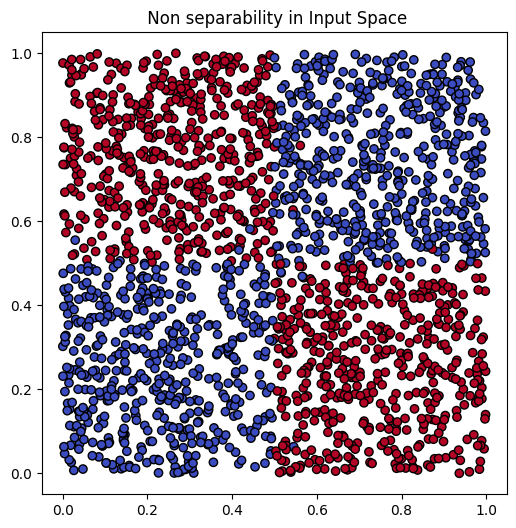

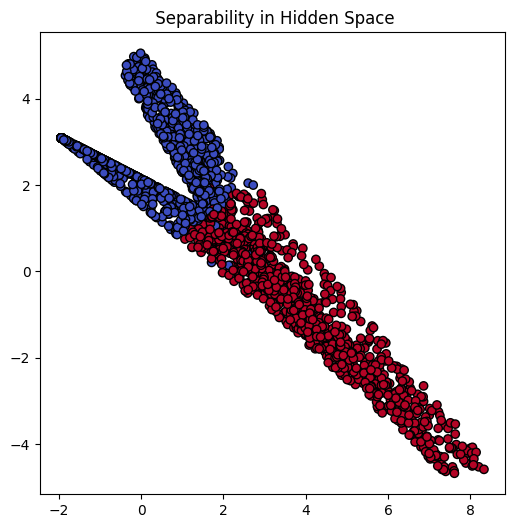

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=labels, cmap="coolwarm", edgecolors='k')
plt.title(" Non separability in Input Space")

plt.figure(figsize=(6,6))

plt.scatter(H[:,0], H[:,1], c=labels, cmap="coolwarm", edgecolors='k')
plt.title(" Separability in Hidden Space")
plt.show()


# **Autoencoders**

## Initialization

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict
torch.manual_seed(42)

## Load MNIST dataset

In [ ]:

# -------------------------
# 1. Load dataset (MNIST)
# -------------------------
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

# Flatten → automatically defines input_dim
X_train = train_dataset.data.float().view(len(train_dataset), -1) / 255.0
X_test  = test_dataset.data.float().view(len(test_dataset), -1) / 255.0



## PCA

In [ ]:
latent_dim = 6   # compression dimension

input_dim = X_train.shape[1]
print(f"Input dim: {input_dim} | Latent dim: {latent_dim}")

# -------------------------
# 2. PCA
# -------------------------
pca = PCA(n_components=latent_dim)

X_train_pca = pca.fit_transform(X_train.numpy())
X_test_pca  = pca.transform(X_test.numpy())

X_test_recon_pca = pca.inverse_transform(X_test_pca)
pca_mse = np.mean((X_test.numpy() - X_test_recon_pca)**2)

print(f" PCA Test MSE: {pca_mse:.6f}")


Input dim: 784 | Latent dim: 6
 PCA Test MSE: 0.041647


## DNN architectures: AE and VAE

In [ ]:
# -------------------------
# 3. Autoencoder (parametric)
# -------------------------
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden):
        super().__init__()

        self.encoder = nn.Sequential(OrderedDict([
            ("enc_linear1", nn.Linear(input_dim, 2 * hidden)),
            ("enc_relu1", nn.ReLU()),
            ("enc_linear2", nn.Linear(2 * hidden, hidden)),
            ("enc_relu2", nn.ReLU()),
            ("enc_linear3", nn.Linear(hidden, latent_dim)),
        ]))

        self.decoder = nn.Sequential(OrderedDict([
            ("dec_linear1", nn.Linear(latent_dim, hidden)),
            ("dec_relu1", nn.ReLU()),
            ("dec_linear2", nn.Linear(hidden, 2 * hidden)),
            ("dec_relu2", nn.ReLU()),
            ("dec_linear3", nn.Linear(2 * hidden, input_dim)),
            ("dec_sigmoid", nn.Sigmoid()),
        ]))

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)


def ae_loss(recon_x, x, z, beta):
    recon_loss = nn.functional.binary_cross_entropy(
        recon_x, x, reduction='sum'
    ) / x.size(0)

    latent_reg = torch.mean(z.pow(2))  # regularization

    return recon_loss + beta * latent_reg

# -------------------------
# 4. Variational Autoencoder
# -------------------------
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, 2*hidden)
        self.fc2 = nn.Linear(2*hidden, hidden)

        # Latent mean and log-variance
        self.fc_mu = nn.Linear(hidden, latent_dim)
        self.fc_logvar = nn.Linear(hidden, latent_dim)

        # Decoder
        self.fc3 = nn.Linear(latent_dim, hidden)
        self.fc4 = nn.Linear(hidden, 2*hidden)
        self.fc5 = nn.Linear(2*hidden, input_dim)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        h = torch.relu(self.fc2(h))
        return self.fc_mu(h), self.fc_logvar(h)

    def generate(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc3(z))
        h = torch.relu(self.fc4(h))
        return torch.sigmoid(self.fc5(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.generate(mu, logvar)
        return self.decode(z), mu, logvar


# VAE loss
def vae_loss(recon_x, x, mu, logvar, beta):
    recon_loss = nn.functional.binary_cross_entropy(
        recon_x, x, reduction='sum'
    ) / x.size(0)

    kl = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    ) / x.size(0)

    return recon_loss + beta * kl




## AE and VAE Training

In [ ]:
# -------------------------
# 5. DataLoader
# -------------------------
batch_size = 128
train_loader = torch.utils.data.DataLoader(X_train, batch_size=batch_size, shuffle=True)

# -------------------------
# 6. Train AE and VAE
# -------------------------
hidden=24
ae_model = Autoencoder(input_dim, latent_dim, hidden=hidden)
vae_model = VAE(input_dim, latent_dim, hidden=hidden)

ae_optimizer = optim.Adam(ae_model.parameters(), lr=1e-3)
vae_optimizer = optim.Adam(vae_model.parameters(), lr=1e-3)

epochs = 10
ae_losses = []
vae_losses = []

for epoch in range(epochs):
    ae_epoch_loss = 0.0
    vae_epoch_loss = 0.0

    for xb in train_loader:
        xb = xb.view(-1, input_dim)

        # ---- AE ----
        ae_optimizer.zero_grad()
        recon = ae_model(xb)
        ae_loss = nn.functional.mse_loss(recon, xb)
        ae_loss.backward()
        ae_optimizer.step()
        ae_epoch_loss += ae_loss.item() * xb.size(0)

        # ---- VAE ----
        vae_optimizer.zero_grad()
        recon, mu, logvar = vae_model(xb)
        loss = vae_loss(recon, xb, mu, logvar,beta=0.5)
        loss.backward()
        vae_optimizer.step()
        vae_epoch_loss += loss.item() * xb.size(0)

    ae_epoch_loss /= len(train_loader.dataset)
    vae_epoch_loss /= len(train_loader.dataset)

    ae_losses.append(ae_epoch_loss)
    vae_losses.append(vae_epoch_loss)

    print(f"Epoch {epoch+1} | AE: {ae_epoch_loss:.5f} | VAE: {vae_epoch_loss:.5f}")



Epoch 1 | AE: 0.07401 | VAE: 226.12381
Epoch 2 | AE: 0.04878 | VAE: 171.72484
Epoch 3 | AE: 0.04182 | VAE: 149.89680
Epoch 4 | AE: 0.03685 | VAE: 142.46840
Epoch 5 | AE: 0.03453 | VAE: 138.18007
Epoch 6 | AE: 0.03313 | VAE: 135.50661
Epoch 7 | AE: 0.03210 | VAE: 132.81888
Epoch 8 | AE: 0.03135 | VAE: 128.98232
Epoch 9 | AE: 0.03084 | VAE: 127.27107
Epoch 10 | AE: 0.03042 | VAE: 126.22072


## Evaluation

In [ ]:
# -------------------------
# 7. Evaluation
# -------------------------
ae_model.eval()
vae_model.eval()

with torch.no_grad():
    X_test_tensor = X_test.view(-1, input_dim)

    # AE
    ae_recon = ae_model(X_test_tensor)
    ae_mse = nn.functional.mse_loss(ae_recon, X_test_tensor).item()

    # VAE
    vae_recon, _, _ = vae_model(X_test_tensor)
    vae_mse = nn.functional.mse_loss(vae_recon, X_test_tensor).item()

print("\n Final Results:")
print(f"PCA MSE : {pca_mse:.6f}")
print(f"AE  MSE : {ae_mse:.6f}")
print(f"VAE MSE : {vae_mse:.6f}")




 Final Results:
PCA MSE : 0.041647
AE  MSE : 0.029942
VAE MSE : 0.029651


## Visualization

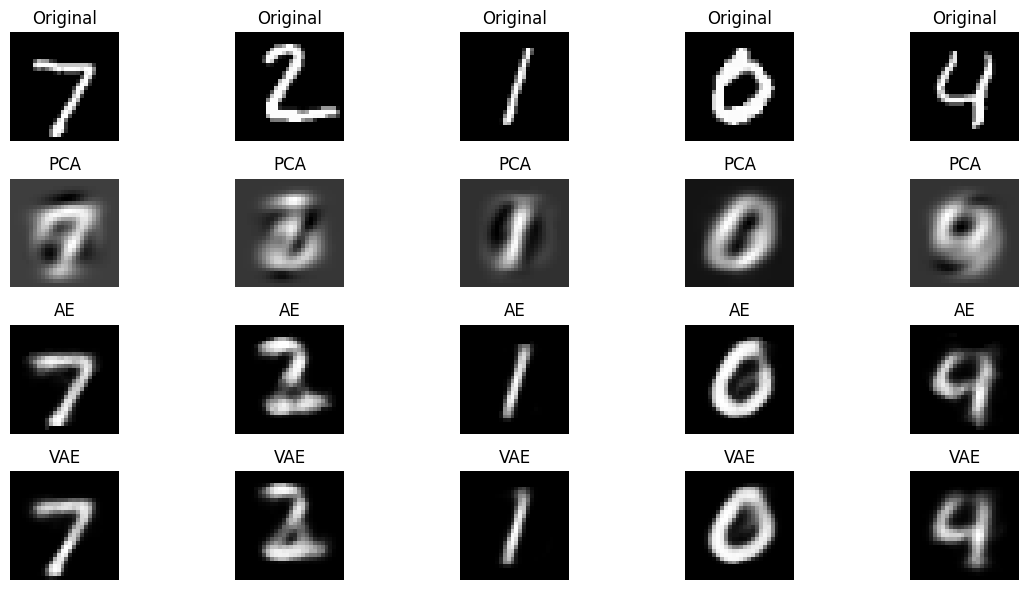

In [ ]:
# -------------------------
# 8. Visualization
# -------------------------
n = 5
plt.figure(figsize=(12,6))

for i in range(n):
    plt.subplot(4, n, i+1)
    plt.imshow(X_test[i].view(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(4, n, i+n+1)
    plt.imshow(X_test_recon_pca[i].reshape(28,28), cmap='gray')
    plt.title("PCA")
    plt.axis('off')

    plt.subplot(4, n, i+2*n+1)
    plt.imshow(ae_recon[i].view(28,28).numpy(), cmap='gray')
    plt.title("AE")
    plt.axis('off')

    plt.subplot(4, n, i+3*n+1)
    plt.imshow(vae_recon[i].view(28,28).numpy(), cmap='gray')
    plt.title("VAE")
    plt.axis('off')

plt.tight_layout()
plt.show()



## Image generation

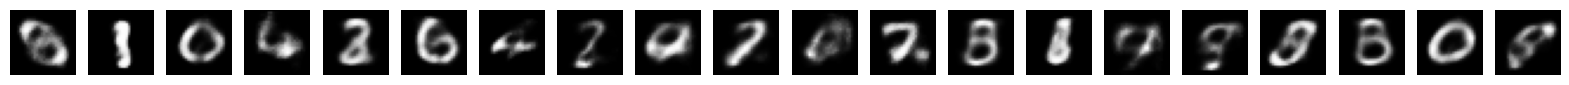

In [ ]:
def generate_vae(model, num_samples=10, latent_dim=6, device="cpu"):
    model.eval()

    with torch.no_grad():
        # Sample from standard normal distribution
        z = torch.randn(num_samples, latent_dim).to(device)

        # Decode to image space
        generated = model.decode(z)

        return generated.view(-1, 28, 28)


def show_images(images, n=10):
    plt.figure(figsize=(n, 2))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(images[i].cpu().numpy(), cmap='gray')
        plt.axis('off')
    plt.show()

# Example usage
N=20
vae_samples = generate_vae(vae_model, num_samples=N, latent_dim=latent_dim)
show_images(vae_samples,n=N)


# Conditional VAE

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 501kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.68MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.5MB/s]


Epoch 1, Loss: 9830411.84
Epoch 2, Loss: 7161603.03
Epoch 3, Loss: 6724896.34
Epoch 4, Loss: 6528563.25
Epoch 5, Loss: 6409619.12
Epoch 6, Loss: 6324770.76
Epoch 7, Loss: 6264603.98
Epoch 8, Loss: 6215046.69
Epoch 9, Loss: 6177629.07
Epoch 10, Loss: 6145637.21


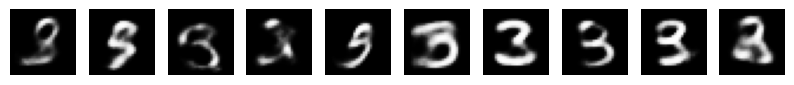

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# =========================
# Hyperparameters
# =========================
batch_size = 128
x_dim = 784
h_dim = 400
z_dim = 20
y_dim = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# DataLoader (MNIST)
# =========================
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

# =========================
# One-hot encoding
# =========================
def one_hot(labels, num_classes=10):
    return F.one_hot(labels, num_classes).float()

# =========================
# CVAE Model
# =========================
class CVAE(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.fc1 = nn.Linear(x_dim + y_dim, h_dim)
        self.fc_mu = nn.Linear(h_dim, z_dim)
        self.fc_logvar = nn.Linear(h_dim, z_dim)

        # Decoder
        self.fc2 = nn.Linear(z_dim + y_dim, h_dim)
        self.fc3 = nn.Linear(h_dim, x_dim)

    def encode(self, x, y):
        xy = torch.cat([x, y], dim=1)
        h = F.relu(self.fc1(xy))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, y):
        zy = torch.cat([z, y], dim=1)
        h = F.relu(self.fc2(zy))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x, y):
        mu, logvar = self.encode(x, y)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z, y)
        return x_recon, mu, logvar


# =========================
# Loss function
# =========================
def loss_function(x_recon, x, mu, logvar):
    recon_loss = F.binary_cross_entropy(x_recon, x, reduction='sum')
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_div





# =========================
# Sampling
# =========================
def sample_digit(digit, num_samples=10):
    model.eval()
    with torch.no_grad():
        z = torch.randn(num_samples, z_dim).to(device)
        labels = torch.tensor([digit] * num_samples).to(device)
        y = one_hot(labels).to(device)

        samples = model.decode(z, y)
        samples = samples.view(-1, 1, 28, 28).cpu()

        # Plot
        fig, axes = plt.subplots(1, num_samples, figsize=(num_samples, 2))
        for i, ax in enumerate(axes):
            ax.imshow(samples[i].squeeze(), cmap="gray")
            ax.axis("off")
        plt.show()






In [8]:
# =========================
# Initialize
# =========================
model = CVAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)
lr = 1e-3
epochs = 100

model.train()

for epoch in range(epochs):
    total_loss = 0

    for x, labels in train_loader:
        x = x.view(-1, 784).to(device)
        y = one_hot(labels).to(device)

        x_recon, mu, logvar = model(x, y)
        loss = loss_function(x_recon, x, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.2f}")

Epoch 1, Loss: 9741020.77
Epoch 2, Loss: 7154325.65
Epoch 3, Loss: 6726191.76
Epoch 4, Loss: 6534576.51
Epoch 5, Loss: 6413669.12
Epoch 6, Loss: 6331695.81
Epoch 7, Loss: 6269712.57
Epoch 8, Loss: 6223661.98
Epoch 9, Loss: 6183659.62
Epoch 10, Loss: 6150525.42
Epoch 11, Loss: 6122686.78
Epoch 12, Loss: 6098222.10
Epoch 13, Loss: 6077101.87
Epoch 14, Loss: 6059777.64
Epoch 15, Loss: 6042663.54
Epoch 16, Loss: 6026168.60
Epoch 17, Loss: 6013660.68
Epoch 18, Loss: 6001123.46
Epoch 19, Loss: 5988978.67
Epoch 20, Loss: 5979059.37
Epoch 21, Loss: 5967663.81
Epoch 22, Loss: 5959515.78
Epoch 23, Loss: 5954385.29
Epoch 24, Loss: 5940181.25
Epoch 25, Loss: 5936270.82
Epoch 26, Loss: 5927355.35
Epoch 27, Loss: 5921497.11
Epoch 28, Loss: 5918861.35
Epoch 29, Loss: 5909424.86
Epoch 30, Loss: 5904174.78
Epoch 31, Loss: 5898377.44


KeyboardInterrupt: 

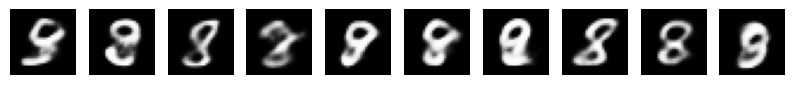

In [7]:
# Generate examples of digit "3"
sample_digit(digit=8, num_samples=10)

# **ConvNet 2D** example

Using device: cuda
Epoch 1: Loss=336.2640, Accuracy=96.38%
Epoch 2: Loss=95.5954, Accuracy=97.73%
Epoch 3: Loss=65.6749, Accuracy=98.28%
Epoch 4: Loss=51.0033, Accuracy=98.44%
Epoch 5: Loss=42.9364, Accuracy=98.49%


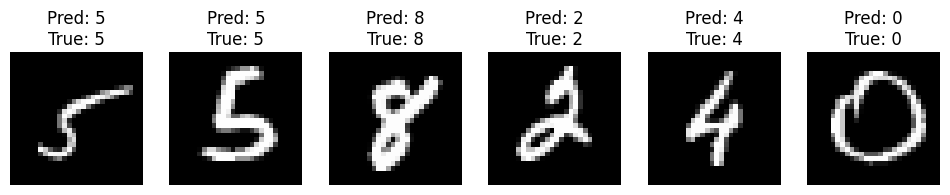

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# ---------------------------
# 1. Device
# ---------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------------------------
# 2. Dataset
# ---------------------------
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=True)

# ---------------------------
# 3. Model
# ---------------------------
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)

        self.fc1 = nn.Linear(16 * 7 * 7, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)

        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


model = SimpleCNN().to(device)

# ---------------------------
# 4. Loss + optimizer
# ---------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# ---------------------------
# 5. Training
# ---------------------------
def train(model, loader):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss


# ---------------------------
# 6. Evaluation
# ---------------------------
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return 100 * correct / total


# ---------------------------
# 7. Visualization
# ---------------------------
def show_predictions(model, loader, n_images=6):
    model.eval()

    images, labels = next(iter(loader))
    images = images.to(device)

    with torch.no_grad():
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

    images = images.cpu()

    plt.figure(figsize=(12, 4))

    for i in range(n_images):
        plt.subplot(1, n_images, i + 1)
        plt.imshow(images[i].squeeze(), cmap="gray")
        plt.title(f"Pred: {preds[i].item()}\nTrue: {labels[i].item()}")
        plt.axis("off")

    plt.show()


# ---------------------------
# 8. Training loop
# ---------------------------
epochs = 5

for epoch in range(epochs):
    loss = train(model, train_loader)
    acc = evaluate(model, test_loader)

    print(f"Epoch {epoch+1}: Loss={loss:.4f}, Accuracy={acc:.2f}%")


# ---------------------------
# 9. Visualize predictions
# ---------------------------
show_predictions(model, test_loader)


# **H-step-forward multivariate forecasting**
n variables, H horizon, T lagged size

* Input  [B,T,n]
* Output [B,H,n]

In [ ]:
# =========================================
# 1. IMPORTS
# =========================================
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)

## Time series generator

In [ ]:


def generate_time_series(
    T=1000,
    dim=3,
    noise_std=0.1,
    freq_scale=1.0,
    coupling_strength=0.2,
    seed=42
):
    """
    Generate a synthetic multivariate time series.

    Parameters:
        T : int
            Number of time steps
        dim : int
            Number of variables (channels)
        noise_std : float
            Gaussian noise standard deviation
        freq_scale : float
            Controls oscillation frequency
        coupling_strength : float
            Cross-variable dependency strength
        seed : int
            Random seed

    Returns:
        X : torch.Tensor of shape (T, dim)
    """

    np.random.seed(seed)

    t = np.linspace(0, 10 * freq_scale, T)

    X = []

    for i in range(dim):
        # Base signal (different frequency & phase per dimension)
        freq = (i + 1) * 0.5
        phase = i * np.pi / 4

        signal = (
            np.sin(freq * t + phase)
            + 0.5 * np.cos(0.5 * freq * t + phase)
        )

        X.append(signal)

    X = np.stack(X, axis=1)

    # Add coupling between variables
    if dim > 1:
        for i in range(dim):
            for j in range(dim):
                if i != j:
                    X[:, i] += coupling_strength * X[:, j]

    # Add nonlinear interaction
    X += 0.3 * np.tanh(X)

    # Add noise
    X += noise_std * np.random.randn(*X.shape)

    return torch.tensor(X, dtype=torch.float32)

def compute_nmse(y_true, y_pred):
    """
    y_true, y_pred: tensors of shape (N, D)
    """
    numerator = torch.sum((y_true - y_pred)**2)
    denominator = torch.sum(y_true**2)

    return (numerator / denominator).item()



def compute_adjacency(x):
    """
    x: (B, T, d)

    returns:
        A: (d, d) correlation matrix
    """

    B, T, d = x.shape

    # Flatten batch + time
    x_flat = x.reshape(B * T, d)
    # (B*T, d)

    # Center data (important for correlation)
    x_mean = x_flat.mean(dim=0, keepdim=True)
    x_centered = x_flat - x_mean
    # (B*T, d)

    # Standard deviation
    std = x_centered.std(dim=0, keepdim=True) + 1e-8

    # Normalize
    x_norm = x_centered / std
    # (B*T, d)

    # Correlation matrix
    A = (x_norm.T @ x_norm) / (B * T)
    # (d, d)

    return A

## Data preparation

In [ ]:


# =========================================
# 2. PARAMETERS
# =========================================
N       = 2000     # time series length
n       = 5        # number of variables
T_in    = 20       # input window
H       = 50        # horizon

batch_size = 64
train_ratio = 0.7
val_ratio   = 0.15

# =========================================
# 3. DATA GENERATION
# =========================================
def generate_time_series(T, dim):
    t = np.linspace(0, 50, T)
    X = []

    for i in range(dim):
        signal = np.sin((i+1)*t) + 0.5*np.cos(0.5*(i+1)*t)
        X.append(signal)

    X = np.stack(X, axis=1)
    X += 0.05 * np.random.randn(*X.shape)

    return torch.tensor(X, dtype=torch.float32)

X = generate_time_series(N, n)

# =========================================
# 4. DATASET CREATION
# =========================================
# Mapping from lagged window to horizon window
def create_dataset(X, T_in, H):
    Xs, Ys = [], []
    for i in range(len(X) - T_in - H):
        Xs.append(X[i:i+T_in])
        Ys.append(X[i+T_in:i+T_in+H])
    return torch.stack(Xs), torch.stack(Ys)

X_seq, Y_seq = create_dataset(X, T_in, H)

# =========================================
# 5. SPLIT
# =========================================
N_train = int(train_ratio * len(X_seq))
N_val   = int(val_ratio * len(X_seq))

X_train = X_seq[:N_train]
Y_train = Y_seq[:N_train]
X_val   = X_seq[N_train:N_train+N_val]
Y_val   = Y_seq[N_train:N_train+N_val]
X_test  = X_seq[N_train+N_val:]
Y_test  = Y_seq[N_train+N_val:]

print("X_train.shape=",X_train.shape)
print("Y_train.shape=",Y_train.shape)

train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val, Y_val), batch_size=batch_size)
test_loader  = DataLoader(TensorDataset(X_test, Y_test), batch_size=batch_size)

Adj=compute_adjacency(X_train)

X_train.shape= torch.Size([1351, 20, 5])
Y_train.shape= torch.Size([1351, 50, 5])


In [ ]:
N_train

1351

## DNN architectures
* FNN: Feefdforward
* TCN: Time convolutional network
* STGCN: Spatio Temporal Graph convolutional based on Adjacency matrix
* RNN
* LSTM
* GRU
* Seq2Seq

All with same input/output shapes:

input [B,T,n] -> output [B, H, n]

where
* n number of variables,
* H multi-step horizon,
* T lagged window size

In [ ]:
# =========================================
# 6. MODELS
# =========================================

# ---- VAR (linear autoregressive) ----
class VAR(nn.Module):
    def __init__(self, d, H, T_in):
        super().__init__()

        self.d = d
        self.H = H
        self.T_in = T_in

        # Linear VAR mapping
        self.fc = nn.Linear(T_in * d, H * d)
        # Input:  (B, T_in*d)
        # Output: (B, H*d)

    def forward(self, x):
        # x: (B, T_in, d)

        x = x.reshape(x.size(0), -1)
        # flatten time + features
        # (B, T_in*d)

        return self.fc(x)
        # (B, T_in*d) → (B, H*d)


# ---- FNN ----
class FNN(nn.Module):
    def __init__(self, d, H, T_in, hidden=128):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(T_in*d, hidden),
            # Input:  (B, T_in*d)
            # Output: (B, hidden)

            nn.ReLU(),
            # (B, hidden) → (B, hidden)

            nn.Linear(hidden, hidden),
            # Input:  (B, hidden)
            # Output: (B, hidden)

            nn.ReLU(),
            # (B, hidden) → (B, hidden)

            nn.Linear(hidden, H*d)
            # Input:  (B, hidden)
            # Output: (B, H*d)
        )

    def forward(self, x):
        # x: (B, T_in, d)

        x = x.view(x.size(0), -1)
        # flatten time and features
        # (B, T_in, d) → (B, T_in*d)

        return self.net(x)
        # (B, T_in*d) → (B, H*d)


# ---- TCN ----
class TCN(nn.Module):
    def __init__(self, d, H):
        super().__init__()

        self.conv1 = nn.Conv1d(d, 32, kernel_size=3, padding=2, dilation=2)
        # Input:  (B, d,  T)
        # Output: (B, 32, T)

        self.conv2 = nn.Conv1d(32, 32, kernel_size=3, padding=4, dilation=4)
        # Input:  (B, 32, T)
        # Output: (B, 32, T)

        self.relu = nn.ReLU()

        self.fc = nn.Linear(32, H*d)
        # Input:  (B, 32)
        # Output: (B, H*d)

    def forward(self, x):
        # x: (B, T, d)

        x = x.permute(0, 2, 1)
        # (B, d, T)

        x = self.relu(self.conv1(x))
        # conv1: (B, d, T) → (B, 32, T)
        # relu: same shape
        # (B, 32, T)

        x = self.relu(self.conv2(x))
        # conv2: (B, 32, T) → (B, 32, T)
        # relu: same shape
        # (B, 32, T)

        x = x[:, :, -1]
        # take last timestep
        # (B, 32)

        return self.fc(x)
        # (B, 32) → (B, H*d)

class STGCN(nn.Module):
    def __init__(self, d, H, Adj):
        super().__init__()

        self.N = d
        self.H = H

        self.conv1 = nn.Conv2d(
            1, 32,
            kernel_size=(3, 1), padding=(2, 0), dilation=(2, 1)
        )
        # (B, 1, T, N) → (B, 32, T, N)

        self.conv2 = nn.Conv2d(
            32, 32,
            kernel_size=(3, 1), padding=(4, 0), dilation=(4, 1)
        )
        # (B, 32, T, N) → (B, 32, T, N)

        self.relu = nn.ReLU()

        self.Adj = Adj

        self.fc = nn.Linear(32 * d, H * d)
        # Input:  (B, 32*d)
        # Output: (B, H*d)

    def forward(self, x):
        """
        x: (B, T, d)
        """

        A = self.Adj

        # --- reshape ---
        x = x.unsqueeze(-1)
        # (B, T, d) → (B, T, d, 1)

        x = x.permute(0, 3, 1, 2)
        # (B, 1, T, d)

        # --- Temporal convs ---
        x = self.relu(self.conv1(x))
        # (B, 32, T, d)

        x = self.relu(self.conv2(x))
        # (B, 32, T, d)

        # --- Graph propagation ---
        x = x.permute(0, 2, 3, 1)
        # (B, T, d, 32)

        x = torch.matmul(A, x)
        # (B, T, d, 32)

        # --- Last timestep ---
        x = x[:, -1]
        # (B, d, 32)

        # ✅ --- Flatten instead of averaging ---
        x = x.reshape(x.size(0), -1)
        # (B, d*32)

        # --- Final prediction ---
        return self.fc(x)
        # (B, H*d)


# ---- RNN / LSTM / GRU ----
class RNNModel(nn.Module):
    def __init__(self, d, H, mode="RNN", hidden=64):
        super().__init__()

        if mode == "RNN":
            self.rnn = nn.RNN(input_size=d, hidden_size=hidden, batch_first=True)
            # Input:  (B, T, d)
            # Output: out → (B, T, hidden)
            # Hidden state h_n: (1, B, hidden)

        elif mode == "LSTM":
            self.rnn = nn.LSTM(d, hidden, batch_first=True)
            # Input:  (B, T, d)
            # Output: out → (B, T, hidden)
            # Hidden states:
            #   h_n: (1, B, hidden)
            #   c_n: (1, B, hidden)

        else:
            self.rnn = nn.GRU(d, hidden, batch_first=True)
            # Input:  (B, T, d)
            # Output: out → (B, T, hidden)
            # Hidden state h_n: (1, B, hidden)

        self.fc = nn.Linear(hidden, H*d)
        # Input:  (B, hidden)
        # Output: (B, H*d)

    def forward(self, x):
        # x: (B, T, d)

        out, _ = self.rnn(x)
        # out: (B, T, hidden)
        # _   : hidden state(s), shape depends on RNN/LSTM/GRU

        out = out[:, -1]
        # take last timestep
        # (B, hidden)

        return self.fc(out)
        # (B, hidden) → (B, H*d)


class Seq2SeqLSTM(nn.Module):
    def __init__(self, d, H, hidden=64):
        super().__init__()
        self.H = H

        self.encoder = nn.LSTM(d, hidden, batch_first=True)
        # Input:  (B, T, d)
        # Output: (B, T, hidden), plus (h, c)
        # h, c: (1, B, hidden)

        self.decoder = nn.LSTM(d, hidden, batch_first=True)
        # Input:  (B, H, d)
        # Output: (B, H, hidden), plus (h, c)

        self.fc = nn.Linear(hidden, d)
        # Input:  (B, H, hidden)
        # Output: (B, H, d)

    def forward(self, x):
        # x: (B, T, d)

        B = x.size(0)
        # scalar = batch size

        _, (h, c) = self.encoder(x)
        # encoder output ignored
        # h: (1, B, hidden)
        # c: (1, B, hidden)

        dec_input = x[:, -1:].repeat(1, self.H, 1)
        # x[:, -1:] → (B, 1, d)   (last timestep)
        # repeat → (B, H, d)
        # decoder input sequence

        out, _ = self.decoder(dec_input, (h, c))
        # Input:  (B, H, d)
        # Initial state: (h, c) = (1, B, hidden)
        # Output: (B, H, hidden)

        out = self.fc(out)
        # (B, H, d)

        return out.reshape(B, -1)
        # (B, H * d)





# ---- Transformer ----
class TransformerModel(nn.Module):
    def __init__(self, d, H, hidden=64, nhead=4, num_layers=2):
        super().__init__()

        # Embedding to hidden dimension
        self.input_proj = nn.Linear(d, hidden)
        # Input:  (B, T, d)
        # Output: (B, T, hidden)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden,
            nhead=nhead,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )
        # Input:  (B, T, hidden)
        # Output: (B, T, hidden)

        # Final projection
        self.fc = nn.Linear(hidden, H*d)
        # Input:  (B, hidden)
        # Output: (B, H*d)

    def forward(self, x):
        # x: (B, T, d)

        x = self.input_proj(x)
        # (B, T, hidden)

        x = self.transformer(x)
        # (B, T, hidden)

        x = x[:, -1]
        # take last timestep (same design as RNN)
        # (B, hidden)

        return self.fc(x)
        # (B, hidden) → (B, H*d)


from sklearn.ensemble import RandomForestRegressor
import torch

# ---- Random Forest ----
class RF:
    def __init__(self, d, H, T_in, n_estimators=100):

        self.d = d
        self.H = H
        self.T_in = T_in

        # sklearn RF
        self.rf = RandomForestRegressor(n_estimators=n_estimators)

    def fit(self, x, y):
        """
        x: (B, T_in, d)
        y: (B, H*d)
        """

        B = x.shape[0]

        # flatten input
        x_flat = x.reshape(B, -1)
        # (B, T_in*d)

        y_flat = y.reshape(B, -1)
        # (B, H*d)

        self.rf.fit(x_flat, y_flat)

    def predict(self, x):
        """
        x: (B, T_in, d)
        """

        B = x.shape[0]

        x_flat = x.reshape(B, -1)
        # (B, T_in*d)

        y_pred = self.rf.predict(x_flat)
        # (B, H*d)

        return torch.tensor(y_pred, dtype=torch.float32)


## Training

In [ ]:
# =========================================
# 7. TRAIN FUNCTION
# =========================================
def train(model,  epochs=20, verbose=False):

    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    train_losses, val_losses = [], []
    first=True
    for epoch in range(epochs):

        # training
        model.train()
        tr_loss = 0

        for xb, yb in train_loader:
            yb_flat = yb.view(yb.size(0), -1)

            optimizer.zero_grad()

            if first:
                print(xb.shape)
                print(yb.shape)
                first=False

            preds = model(xb)
            loss = criterion(preds, yb_flat)

            loss.backward()
            optimizer.step()
            tr_loss += loss.item() * xb.size(0)

        # validation
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for xb, yb in val_loader:
                yb_flat = yb.view(yb.size(0), -1)


                preds = model(xb)
                loss = criterion(preds, yb_flat)

                val_loss += loss.item() * xb.size(0)

        train_losses.append(tr_loss / len(train_loader.dataset))
        val_losses.append(val_loss / len(val_loader.dataset))
        if verbose:
          if epoch%10==0:
            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_losses[-1]:.5f} | Val Loss: {val_losses[-1]:.5f}")
    return train_losses, val_losses

# =========================================
# 8. NMSE
# =========================================
def compute_nmse(y_true, y_pred):
    return (torch.sum((y_true - y_pred)**2) / torch.sum(y_true**2)).item()

# =========================================
# 9. TRAIN ALL MODELS
# =========================================
models = {
    "VAR": VAR(n, H, T_in),
    "FNN": FNN( n, H, T_in),
    "TCN": TCN(n, H),
    "STGCN": STGCN(n, H, Adj),
    "RNN": RNNModel(n, H, "RNN"),
    "LSTM": RNNModel(n, H, "LSTM"),
    "GRU": RNNModel(n, H, "GRU"),
    "Seq2Seq": Seq2SeqLSTM(n, H),
    "Transf": TransformerModel(n, H, nhead=2)
}

histories = {}


## input [B,T,n] -> output [B, H, n]

for name, model in models.items():
    print(f"Training {name}")
    histories[name] = train(model, verbose=True)



Training VAR
torch.Size([64, 20, 5])
torch.Size([64, 50, 5])
Epoch 1/20 | Train Loss: 0.59382 | Val Loss: 0.42697
Epoch 11/20 | Train Loss: 0.12495 | Val Loss: 0.14434
Training FNN
torch.Size([64, 20, 5])
torch.Size([64, 50, 5])
Epoch 1/20 | Train Loss: 0.53973 | Val Loss: 0.38167
Epoch 11/20 | Train Loss: 0.00557 | Val Loss: 0.00665
Training TCN
torch.Size([64, 20, 5])
torch.Size([64, 50, 5])
Epoch 1/20 | Train Loss: 0.62972 | Val Loss: 0.60545
Epoch 11/20 | Train Loss: 0.11524 | Val Loss: 0.14257
Training STGCN
torch.Size([64, 20, 5])
torch.Size([64, 50, 5])
Epoch 1/20 | Train Loss: 0.59649 | Val Loss: 0.52492
Epoch 11/20 | Train Loss: 0.08526 | Val Loss: 0.10326
Training RNN
torch.Size([64, 20, 5])
torch.Size([64, 50, 5])
Epoch 1/20 | Train Loss: 0.59726 | Val Loss: 0.52712
Epoch 11/20 | Train Loss: 0.07617 | Val Loss: 0.07961
Training LSTM
torch.Size([64, 20, 5])
torch.Size([64, 50, 5])
Epoch 1/20 | Train Loss: 0.61366 | Val Loss: 0.57212
Epoch 11/20 | Train Loss: 0.02805 | Val Los

AttributeError: 'RF' object has no attribute 'parameters'

## Evaluation and visualization

Evaluating VAR
Evaluating FNN
Evaluating TCN
Evaluating STGCN
Evaluating RNN
Evaluating LSTM
Evaluating GRU
Evaluating Seq2Seq
Evaluating Transf

✅ Test Results
VAR        | MSE=0.08292 | NMSE=0.13928
FNN        | MSE=0.00403 | NMSE=0.00677
TCN        | MSE=0.03957 | NMSE=0.06647
STGCN      | MSE=0.04845 | NMSE=0.08138
RNN        | MSE=0.03521 | NMSE=0.05914
LSTM       | MSE=0.00703 | NMSE=0.01181
GRU        | MSE=0.01191 | NMSE=0.02000
Seq2Seq    | MSE=0.01346 | NMSE=0.02260
Transf     | MSE=0.00489 | NMSE=0.00821


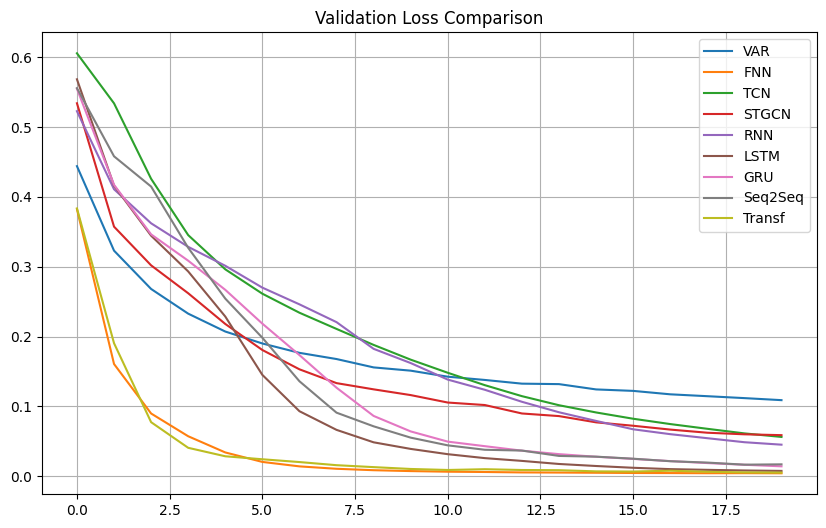

In [ ]:
# =========================================
# 10. EVALUATION
# =========================================
criterion = nn.MSELoss()
results_mse = {}
results_nmse = {}

for name, model in models.items():
    print(f"Evaluating {name}")
    model.eval()
    preds_all, targets_all = [], []
    total_loss = 0

    with torch.no_grad():
        for xb, yb in test_loader:
            yb_flat = yb.view(yb.size(0), -1)


            preds = model(xb)

            total_loss += criterion(preds, yb_flat).item() * xb.size(0)

            preds_all.append(preds)
            targets_all.append(yb_flat)

    mse = total_loss / len(test_loader.dataset)

    preds_all = torch.cat(preds_all)
    targets_all = torch.cat(targets_all)

    nmse = compute_nmse(targets_all, preds_all)

    results_mse[name] = mse
    results_nmse[name] = nmse

# =========================================
# 11. RESULTS
# =========================================
print("\n✅ Test Results")
for k in models:
    print(f"{k:10s} | MSE={results_mse[k]:.5f} | NMSE={results_nmse[k]:.5f}")

# =========================================
# 12. PLOT
# =========================================
plt.figure(figsize=(10,6))
for name, (_, val_loss) in histories.items():
    plt.plot(val_loss, label=name)

plt.legend()
plt.title("Validation Loss Comparison")
plt.grid()
plt.show()

In [ ]:
len(test_loader.dataset)

290

## Classification with FNN and GAN

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# MNIST
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)

class FNNClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

fnn = FNNClassifier().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(fnn.parameters(), lr=1e-3)

epochs = 5

for epoch in range(epochs):
    fnn.train()
    total_loss = 0

    for x, y in train_loader:
        x = x.view(-1, 784).to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = fnn(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"FNN Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f}")


def evaluate(model):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in test_loader:
            x = x.view(-1, 784).to(device)
            y = y.to(device)

            logits = model(x)
            preds = torch.argmax(logits, dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

fnn_acc = evaluate(fnn)
print(f"\n✅ FNN Test Accuracy: {fnn_acc:.4f}")



FNN Epoch 1 | Loss: 0.3529
FNN Epoch 2 | Loss: 0.1333
FNN Epoch 3 | Loss: 0.0891
FNN Epoch 4 | Loss: 0.0643
FNN Epoch 5 | Loss: 0.0490

✅ FNN Test Accuracy: 0.9746


In [ ]:
class Generator(nn.Module):
    def __init__(self, noise_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.feature = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2)
        )

        # Outputs
        self.adv_head = nn.Linear(256, 1)   # real/fake
        self.cls_head = nn.Linear(256, 10)  # class

    def forward(self, x):
        features = self.feature(x)
        adv_out = torch.sigmoid(self.adv_head(features))
        cls_out = self.cls_head(features)
        return adv_out, cls_out


G = Generator().to(device)
D = Discriminator().to(device)

adv_loss = nn.BCELoss()
cls_loss = nn.CrossEntropyLoss()

g_optimizer = optim.Adam(G.parameters(), lr=2e-4)
d_optimizer = optim.Adam(D.parameters(), lr=2e-4)

noise_dim = 100

epochs = 5

for epoch in range(epochs):
    for x, y in train_loader:
        x = x.view(-1, 784).to(device)
        y = y.to(device)
        batch_size = x.size(0)

        # Real/Fake labels
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # ------------------
        # Train Discriminator
        # ------------------
        z = torch.randn(batch_size, noise_dim).to(device)
        fake_images = G(z)

        d_optimizer.zero_grad()

        # Real data
        real_adv, real_cls = D(x)
        d_real_loss = adv_loss(real_adv, real_labels) + cls_loss(real_cls, y)

        # Fake data
        fake_adv, _ = D(fake_images.detach())
        d_fake_loss = adv_loss(fake_adv, fake_labels)

        d_loss = d_real_loss + d_fake_loss
        d_loss.backward()
        d_optimizer.step()

        # ------------------
        # Train Generator
        # ------------------
        g_optimizer.zero_grad()

        fake_adv, _ = D(fake_images)
        g_loss = adv_loss(fake_adv, real_labels)

        g_loss.backward()
        g_optimizer.step()

    print(f"GAN Epoch {epoch+1} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

def evaluate_discriminator(D):
    D.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in test_loader:
            x = x.view(-1, 784).to(device)
            y = y.to(device)

            _, logits = D(x)
            preds = torch.argmax(logits, dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

gan_acc = evaluate_discriminator(D)

print(f"\n✅ GAN-based classifier Accuracy: {gan_acc:.4f}")

GAN Epoch 1 | D Loss: 0.8065 | G Loss: 8.3501
GAN Epoch 2 | D Loss: 0.6518 | G Loss: 3.2623
GAN Epoch 3 | D Loss: 0.3998 | G Loss: 4.7361
GAN Epoch 4 | D Loss: 0.3250 | G Loss: 6.6219
GAN Epoch 5 | D Loss: 0.3108 | G Loss: 5.3559

✅ GAN-based classifier Accuracy: 0.9341



📊 Plotting predictions for FNN


NameError: name 'T' is not defined

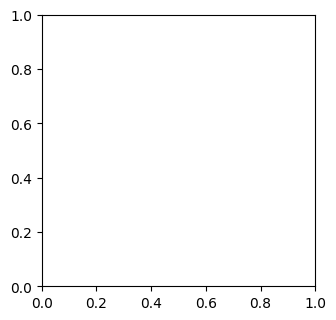

In [ ]:
# =========================
# 7. VISUAL COMPARISON
# =========================

def plot_predictions(model, name, num_examples=3):
    model.eval()
    plt.figure(figsize=(12, 4 * num_examples))

    for i in range(num_examples):
        idx = np.random.randint(0, len(X_test))

        x_input = X_test[idx:idx+1]    # (1, T, d)
        y_true  = Y_test[idx]          # (H, d)

        with torch.no_grad():
            if name == "ProbLSTM":
                mean, _ = model(x_input)
                y_pred = mean.view(H, d)
            else:
                preds = model(x_input)
                y_pred = preds.view(H, d)

        x_input = x_input.squeeze(0)

        for dim in range(d):
            plt.subplot(num_examples, d, i*d + dim + 1)

            # Past (input history)
            plt.plot(range(T), x_input[:, dim], label="Past", color="black")

            # True future
            plt.plot(range(T, T+H), y_true[:, dim], label="True", color="green")

            # Prediction
            plt.plot(range(T, T+H), y_pred[:, dim], '--', label="Pred", color="red")

            plt.title(f"{name} | Sample {i+1} | Dim {dim}")
            plt.legend()
            plt.grid()

    plt.tight_layout()
    plt.show()
for name, model in models.items():
    print(f"\n📊 Plotting predictions for {name}")
    plot_predictions(model, name, num_examples=3)

# CGAN

In [9]:
import torch
import torch.nn as nn
from torch import optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# =========================
# Hyperparameters
# =========================
batch_size = 128
z_dim = 100
y_dim = 10
img_dim = 784
lr = 2e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# DataLoader
# =========================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# =========================
# One-hot encoding
# =========================
def one_hot(labels, num_classes=10):
    return torch.nn.functional.one_hot(labels, num_classes).float()

# =========================
# Generator
# =========================
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(z_dim + y_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, img_dim),
            nn.Tanh()
        )

    def forward(self, z, y):
        zy = torch.cat([z, y], dim=1)
        return self.model(zy)


# =========================
# Discriminator
# =========================
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(img_dim + y_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x, y):
        xy = torch.cat([x, y], dim=1)
        return self.model(xy)


# =========================
# Initialize models
# =========================
G = Generator().to(device)
D = Discriminator().to(device)

opt_G = optim.Adam(G.parameters(), lr=lr)
opt_D = optim.Adam(D.parameters(), lr=lr)

criterion = nn.BCELoss()

# =========================
# Sampling
# =========================
def generate_digit(digit, num_samples=10):
    G.eval()

    with torch.no_grad():
        z = torch.randn(num_samples, z_dim).to(device)
        labels = torch.tensor([digit] * num_samples).to(device)
        y = one_hot(labels).to(device)

        samples = G(z, y)
        samples = samples.view(-1, 1, 28, 28).cpu()

        fig, axes = plt.subplots(1, num_samples, figsize=(num_samples, 2))
        for i, ax in enumerate(axes):
            ax.imshow(samples[i].squeeze(), cmap="gray")
            ax.axis("off")
        plt.show()





In [ ]:
epochs = 100

for epoch in range(epochs):
    for batch_idx, (real, labels) in enumerate(loader):
        real = real.view(-1, 784).to(device)
        y = one_hot(labels).to(device)
        batch_size_current = real.size(0)

        # =====================
        # Train Discriminator
        # =====================
        z = torch.randn(batch_size_current, z_dim).to(device)
        fake = G(z, y)

        real_labels = torch.ones((batch_size_current, 1)).to(device)
        fake_labels = torch.zeros((batch_size_current, 1)).to(device)

        D_real = D(real, y)
        D_fake = D(fake.detach(), y)

        loss_D_real = criterion(D_real, real_labels)
        loss_D_fake = criterion(D_fake, fake_labels)

        loss_D = loss_D_real + loss_D_fake

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # =====================
        # Train Generator
        # =====================
        z = torch.randn(batch_size_current, z_dim).to(device)
        fake = G(z, y)

        output = D(fake, y)
        loss_G = criterion(output, real_labels)  # wants D(fake)=1

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    print(f"Epoch [{epoch+1}/{epochs}] | Loss D: {loss_D.item():.4f}, Loss G: {loss_G.item():.4f}")





Epoch [1/100] | Loss D: 0.0003, Loss G: 9.0300
Epoch [2/100] | Loss D: 0.0000, Loss G: 11.7975
Epoch [3/100] | Loss D: 0.0000, Loss G: 12.6679
Epoch [4/100] | Loss D: 0.0000, Loss G: 13.1632
Epoch [5/100] | Loss D: 0.0000, Loss G: 13.5597
Epoch [6/100] | Loss D: 0.0000, Loss G: 13.9579
Epoch [7/100] | Loss D: 0.0000, Loss G: 14.2507
Epoch [8/100] | Loss D: 0.0000, Loss G: 14.0144
Epoch [9/100] | Loss D: 0.0000, Loss G: 13.5292
Epoch [10/100] | Loss D: 0.0000, Loss G: 14.2341
Epoch [11/100] | Loss D: 0.0000, Loss G: 14.8837
Epoch [12/100] | Loss D: 0.0000, Loss G: 15.2751
Epoch [13/100] | Loss D: 0.0000, Loss G: 15.6844
Epoch [14/100] | Loss D: 0.0000, Loss G: 15.9754
Epoch [15/100] | Loss D: 0.0000, Loss G: 16.2807
Epoch [16/100] | Loss D: 0.0000, Loss G: 16.6123
Epoch [17/100] | Loss D: 0.0000, Loss G: 16.8846
Epoch [18/100] | Loss D: 0.0000, Loss G: 17.1381
Epoch [19/100] | Loss D: 0.0000, Loss G: 70.4547
Epoch [20/100] | Loss D: 0.0000, Loss G: 72.5471
Epoch [21/100] | Loss D: 0.000

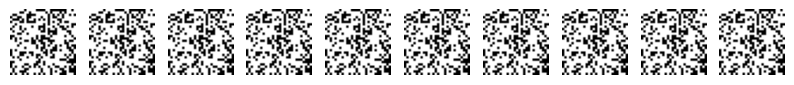

In [12]:
# Generate digit "7"
generate_digit(3, num_samples=10)